# Testing Fujifilm prescale calibration

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = Image.open('prescale-test.png').convert('RGB')
data = np.array(img)

## 1.0 Colour channels

Extract the colour channels here (R,G,B). The staining is magenta, so green should be very low in the staining (red and blue dominate). Green also has the widest dynamic range, so pick it for further analysis.

In [13]:
red = data[:, :, 0].astype(float)
green = data[:, :, 1].astype(float)
blue = data[:, :, 2].astype(float)

# Check the dynamic range of each channel
dr_red = np.diff(red, axis=0)
dr_green = np.diff(green, axis=0)
dr_blue = np.diff(blue, axis=0)
print(f'Red dynamic range: {np.max(np.abs(dr_red))}')
print(f'Green dynamic range: {np.max(np.abs(dr_green))}')
print(f'Blue dynamic range: {np.max(np.abs(dr_blue))}')    

Red dynamic range: 89.0
Green dynamic range: 110.0
Blue dynamic range: 101.0


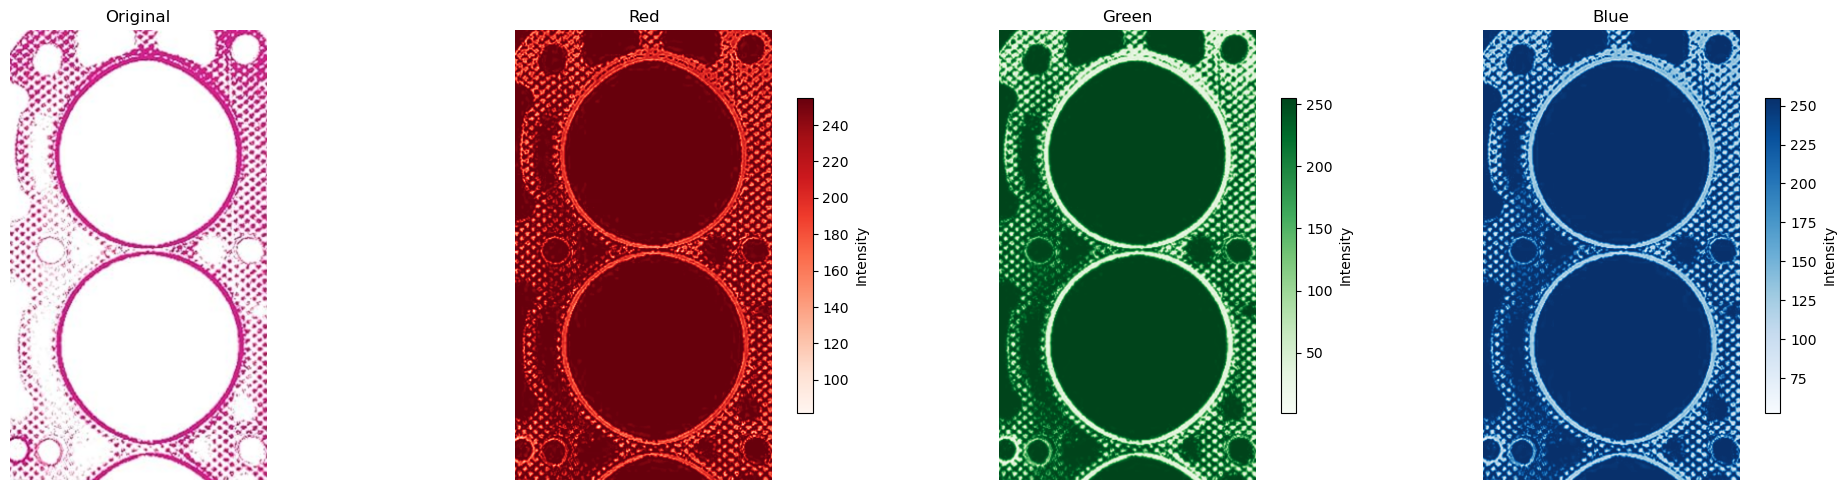

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

im0 = axes[0].imshow(img)
axes[0].set_title('Original')

im1 = axes[1].imshow(red, cmap='Reds')
fig.colorbar(im1, ax=axes[1], shrink=0.7, label='Intensity')
axes[1].set_title('Red')

im2 = axes[2].imshow(green, cmap='Greens')
fig.colorbar(im2, ax=axes[2], shrink=0.7, label='Intensity')
axes[2].set_title('Green')

im3 = axes[3].imshow(blue, cmap='Blues')
fig.colorbar(im3, ax=axes[3], shrink=0.7, label='Intensity')
axes[3].set_title('Blue')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 2.0 Calculate the optical density

**Optical density**

$OD = log_{10}(G_0 / G_t)$

Where $G_0$ is the incident light on a white region of the sample and $G_t$ is the transitted green channel intensity.

**Why optical density?**

1. Raw intensity depends on the scanner hardware and calibration. Optical density divides by a white reference ($G_0$) so the scanner's characteristics cancel out, providing reporducable results.

2. Linearity with dye concentration. Light absorption is logarithmic, so each layer of dye absorbs a set fraction of the remaining light. Taking the log means that the dye concentration scales linearly with the optical density.

In [17]:
# Take a crop of the green channel to compute the white reference
g0 = green[600:700, 200:300].mean()
print(f'White reference G0: {g0}')

green = np.clip(green, 1, None) # Avoid log(0) by clipping to a minimum of 1
od = -np.log10(green / g0)

White reference G0: 255.0


## 3.0 Example calibration data

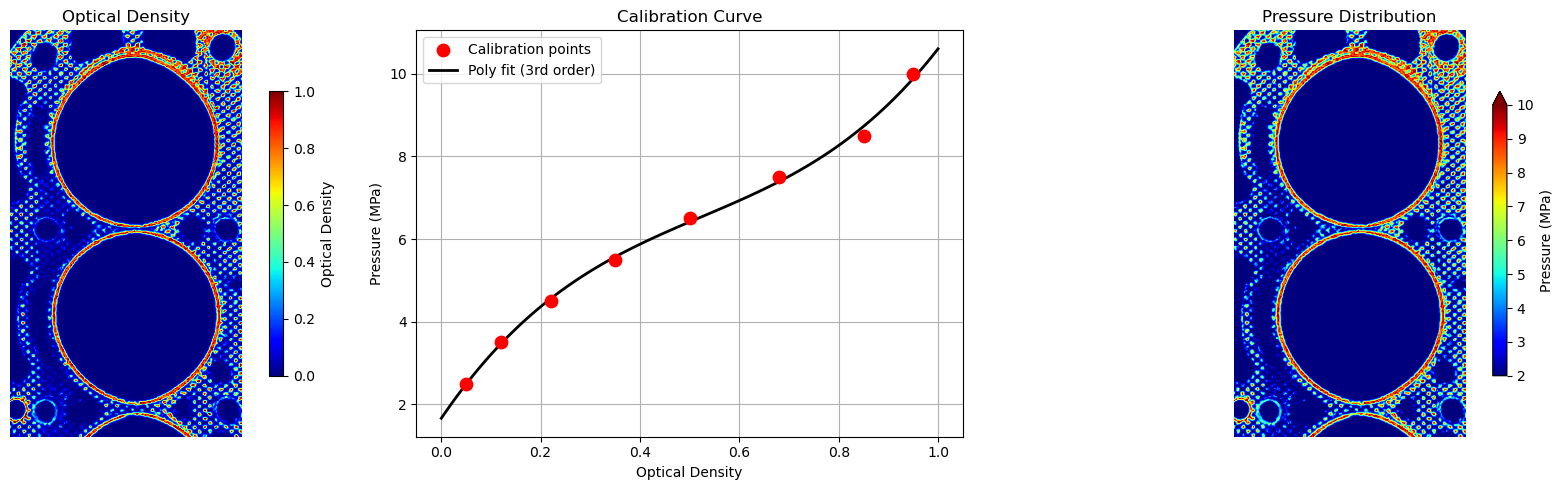

In [25]:
# Calibration data
od_cal = np.array([0.05, 0.12, 0.22, 0.35, 0.50, 0.68, 0.85, 0.95])
p_cal = np.array([2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 10.0])

coeffs = np.polyfit(od_cal, p_cal, 3)
poly = np.poly1d(coeffs)

# Apply calibration
pressure_map = poly(od)
pressure_map = np.clip(pressure_map, 0, 10) # Clip values out of calibration range

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# View optical density
im0 = axes[0].imshow(od, cmap='jet', vmax=1.0)
fig.colorbar(im0, ax=axes[0], shrink=0.7, label='Optical Density')
axes[0].set_title('Optical Density')
axes[0].axis('off')

# View calibration curve
od_fit = np.linspace(0, 1.0, 100)
axes[1].scatter(od_cal, p_cal, color='red', s=80, zorder=5, label='Calibration points')
axes[1].plot(od_fit, poly(od_fit), 'k-', linewidth=2, label='Poly fit (3rd order)')
axes[1].set_xlabel('Optical Density')
axes[1].set_ylabel('Pressure (MPa)')
axes[1].set_title('Calibration Curve')
axes[1].legend()
axes[1].grid(True)

# View pressure map
im2 = axes[2].imshow(pressure_map, cmap='jet', vmin=2, vmax=10)
fig.colorbar(im2, ax=axes[2], shrink=0.7, label='Pressure (MPa)', extend='max')
axes[2].set_title('Pressure Distribution')
axes[2].axis('off')

plt.tight_layout()
plt.show()